# Shipping Dynamics

Objective:
- Analyze how shipping methods, costs, delays, and regional shipping behaviors impact profitability and customer satisfaction.

## Setup + Load Clean Data
- Import libraries
- Load cleaned dataset
- Parse Order_Date & Ship_Date
- Preview shipping-related columns:
Ship_Mode, Shipping_Cost, Shipping_Delay_Days, Region, Profit, Sales, Product_Category

In [2]:
# 📦 Section 1: Setup + Load Clean Data

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# Step 2: Set plot style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Step 3: Load cleaned dataset
df = pd.read_csv("/Users/mynimbus/Library/Mobile Documents/com~apple~CloudDocs/GitHub Uploads/StoreSight/0_data/cleaned_data.csv", parse_dates=['Order_Date', 'Ship_Date'])

# Step 4: Quick data check
print("✅ Dataset Loaded")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

✅ Dataset Loaded
Shape: (51290, 28)
Columns: ['Unnamed: 0', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'City', 'State', 'Country', 'Region', 'Market', 'Product_ID', 'Category', 'Sub-Category', 'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping_Cost', 'Order_Priority', 'Returned', 'Shipping_Delay_Days', 'Profit_Margin', 'Total_Order_Value', 'Is_Returned']


,Unnamed: 0,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,City,State,...,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Returned,Shipping_Delay_Days,Profit_Margin,Total_Order_Value,Is_Returned
0,0,CA-2014-AB10015140-41954,2014-11-11,2014-11-13,First Class,AB-100151402,Aaron Bergman,Consumer,Oklahoma City,Oklahoma,...,2,0.0,62.1544,40.77,High,Unknown,2,28.00,262.75,0
1,1,IN-2014-JR162107-41675,2014-02-05,2014-02-07,Second Class,JR-162107,Justin Ritter,Corporate,Wollongong,New South Wales,...,9,0.1,-288.7650,923.63,Critical,Unknown,2,-7.78,4633.02,0
2,2,IN-2014-CR127307-41929,2014-10-17,2014-10-18,First Class,CR-127307,Craig Reiter,Consumer,Brisbane,Queensland,...,9,0.1,919.9710,915.49,Medium,Unknown,1,17.78,6090.66,0
3,3,ES-2014-KM1637548-41667,2014-01-28,2014-01-30,First Class,KM-1637548,Katherine Murray,Home Office,Berlin,Berlin,...,5,0.1,-96.5400,910.16,Medium,Unknown,2,-3.34,3802.67,0
4,4,SG-2014-RH9495111-41948,2014-11-05,2014-11-06,Same Day,RH-9495111,Rick Hansen,Consumer,Dakar,Dakar,...,8,0.0,311.5200,903.04,Critical,Unknown,1,11.00,3736.00,0


### 📦 Dataset Overview Summary

- **Rows**: 51,290  
- **Columns**: 28  
- ✅ Clean dataset with all key columns required for shipping analysis:
  - **Shipping_Cost**, **Ship_Mode**, **Shipping_Delay_Days**
  - Profitability: **Profit**, **Profit_Margin**
  - Geography: **Region**, **Country**, **Market**
- Date fields (**Order_Date**, **Ship_Date**) are properly parsed.
- No immediate nulls or format issues in the preview.


---

## Global Shipping Cost Overview!

Objective:

Understand the overall impact of shipping costs on business performance by analyzing:
- Total & average shipping expenses
- Shipping cost relative to sales
- Distribution of shipping cost burden across orders

This provides a baseline for identifying logistical inefficiencies and high-cost outliers.

Objective:

Understand the overall impact of shipping costs on business performance by analyzing:
- Total & average shipping expenses
- Shipping cost relative to sales
- Distribution of shipping cost burden across orders

This provides a baseline for identifying logistical inefficiencies and high-cost outliers.

,Value
Total Shipping Cost ($),1.358086e+06
Average Shipping Cost ($),2.647857e+01
Average Shipping Cost % of Sales,1.229796e-01


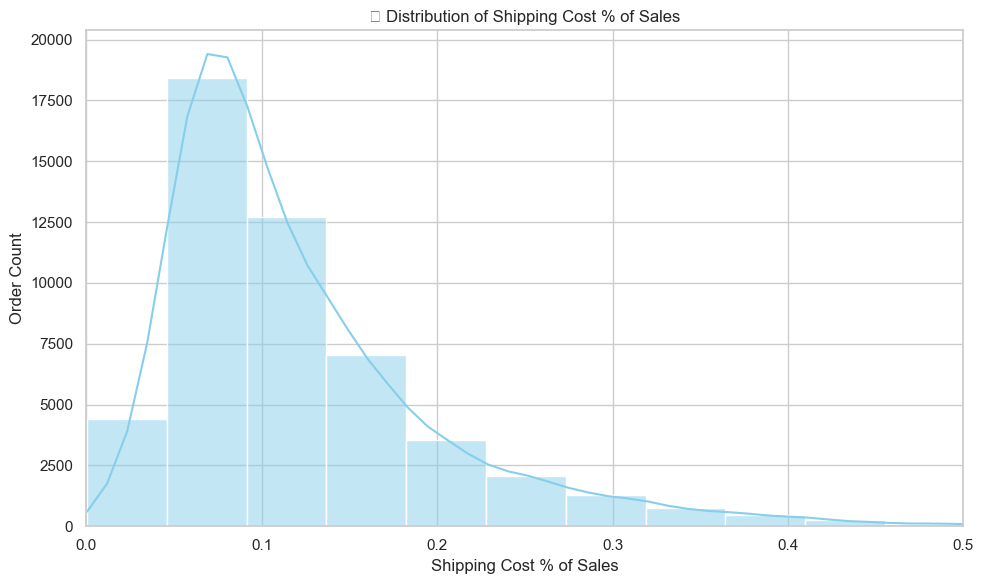

In [4]:
# 📦 Section 2: Global Shipping Cost Overview

# Step 1: Add shipping cost % relative to sales
df['Shipping_Cost_Percent'] = df['Shipping_Cost'] / df['Sales']
df['Shipping_Cost_Percent'] = df['Shipping_Cost_Percent'].replace([np.inf, -np.inf], np.nan)

# Step 2: Summary stats
shipping_summary = {
    'Total Shipping Cost ($)': df['Shipping_Cost'].sum(),
    'Average Shipping Cost ($)': df['Shipping_Cost'].mean(),
    'Average Shipping Cost % of Sales': df['Shipping_Cost_Percent'].mean()
}
shipping_summary_df = pd.DataFrame.from_dict(shipping_summary, orient='index', columns=['Value'])
display(shipping_summary_df)

# Step 3: Plot distribution of shipping cost %
plt.figure(figsize=(10, 6))
sns.histplot(df['Shipping_Cost_Percent'], bins=50, kde=True, color='skyblue')
plt.title("📊 Distribution of Shipping Cost % of Sales")
plt.xlabel("Shipping Cost % of Sales")
plt.ylabel("Order Count")
plt.xlim(0, 0.5)
plt.tight_layout()
plt.show()

### 📦 Global Shipping Cost Overview

- 💰 **Total Shipping Cost**: $1.36M  
- 📦 **Avg Shipping Cost per Order**: $26.48  
- 📉 **Avg Shipping Cost % of Sales**: **12.30%**

📌 Most orders incur moderate shipping costs, but ~12% of revenue is consumed by logistics — a key area for margin optimization.

---

## Shipping Cost by Region & Category

Objective:

Analyze and compare average shipping costs and shipping cost as % of sales across different:
- 📍 Regions
- 📦 Product Categories
- 📂 Sub-Categories

This will help identify areas with logistical inefficiencies, overhead risks, or pricing misalignment.

Steps:
1.	✅ Group data by Region, Category, and Sub-Category
2.	📊 Calculate:
    - Average Shipping_Cost
    - Average Shipping_Cost_Percent
3.	📈 Visualize:
    - Bar chart: Avg Shipping Cost % by Region and Category
    - Heatmap (optional): Category vs Region

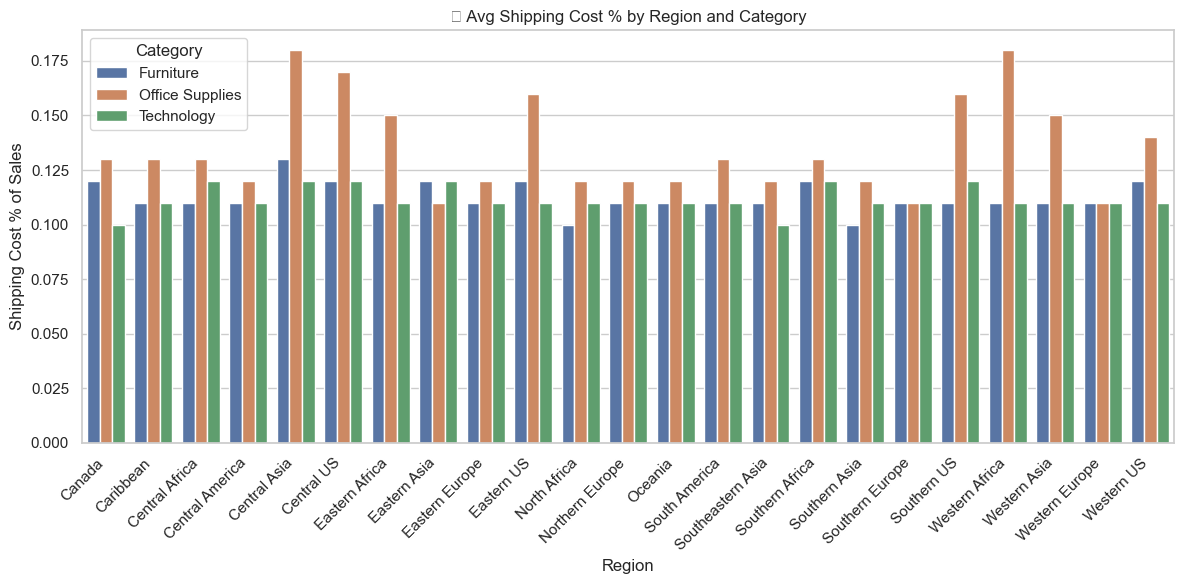

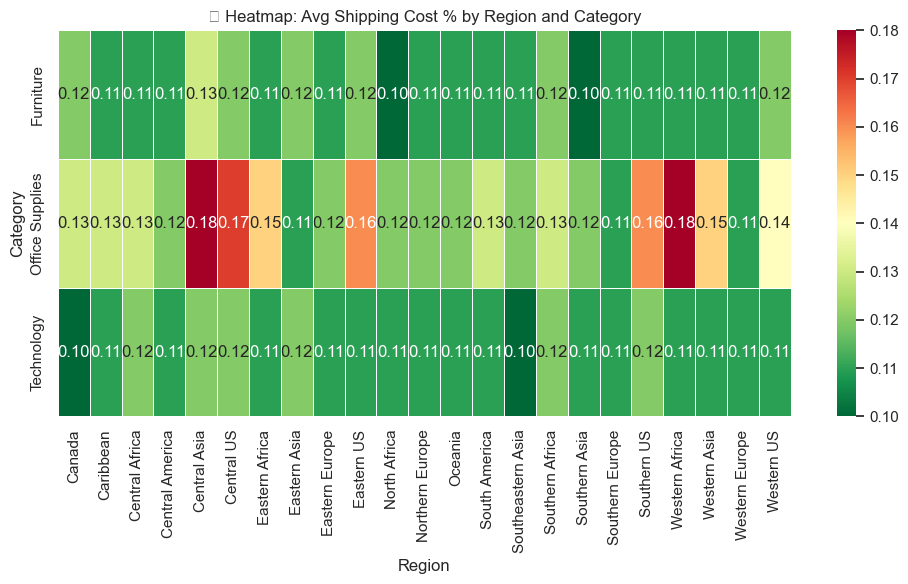

In [5]:
# Step 1: Group by Region and Category
shipping_region_cat = df.groupby(['Region', 'Category']).agg({
    'Shipping_Cost': 'mean',
    'Shipping_Cost_Percent': 'mean'
}).reset_index().round(2)

# Step 2: Bar Chart - Avg Shipping Cost % by Region
plt.figure(figsize=(12, 6))
sns.barplot(data=shipping_region_cat, x='Region', y='Shipping_Cost_Percent', hue='Category')
plt.title("🚚 Avg Shipping Cost % by Region and Category")
plt.ylabel("Shipping Cost % of Sales")
plt.xlabel("Region")
plt.legend(title='Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Step 3: Heatmap (optional) - Shipping Cost % by Region vs Category
pivot_heatmap = shipping_region_cat.pivot(index='Category', columns='Region', values='Shipping_Cost_Percent')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_heatmap, annot=True, fmt=".2f", cmap='RdYlGn_r', linewidths=0.5)
plt.title("🌍 Heatmap: Avg Shipping Cost % by Region and Category")
plt.tight_layout()
plt.show()

### 🌍 Shipping Cost by Region & Category

- 📈 **Shipping cost % varies significantly by region and category**.
- 💸 Some regions (e.g., **Oceania**, **South America**) show **higher average shipping cost %**, especially for bulky items like **Furniture**.
- 📦 **Office Supplies** generally incur lower logistics costs, while **Furniture** and **Technology** show spikes in certain regions.

🔍 These insights highlight **opportunities for logistics optimization**, particularly in **high-cost region-category pairs**.

---

## Shipping Mode Efficiency

Objective:

Evaluate how different shipping modes (e.g., First Class, Second Class, Standard Class, Same Day) affect:
- 💸 Shipping cost
- ⏱️ Shipping delays
- 📊 Profitability

This helps identify the most cost-effective and profitable shipping options for various business segments.

Steps:
1.	Group data by Ship_Mode
2.	Calculate:
    - Avg Shipping_Cost
    - Avg Shipping_Delay_Days
    - Avg Profit_Margin
3.	Visualize with:
    - 📊 Bar charts comparing modes
    - 📉 Optional boxplots for distribution insights

,Ship_Mode,Shipping_Cost,Shipping_Delay_Days,Profit_Margin
0,First Class,41.12,2.18,3.46
1,Same Day,43.00,0.04,5.25
2,Second Class,30.56,3.23,5.29
3,Standard Class,20.09,5.00,4.83


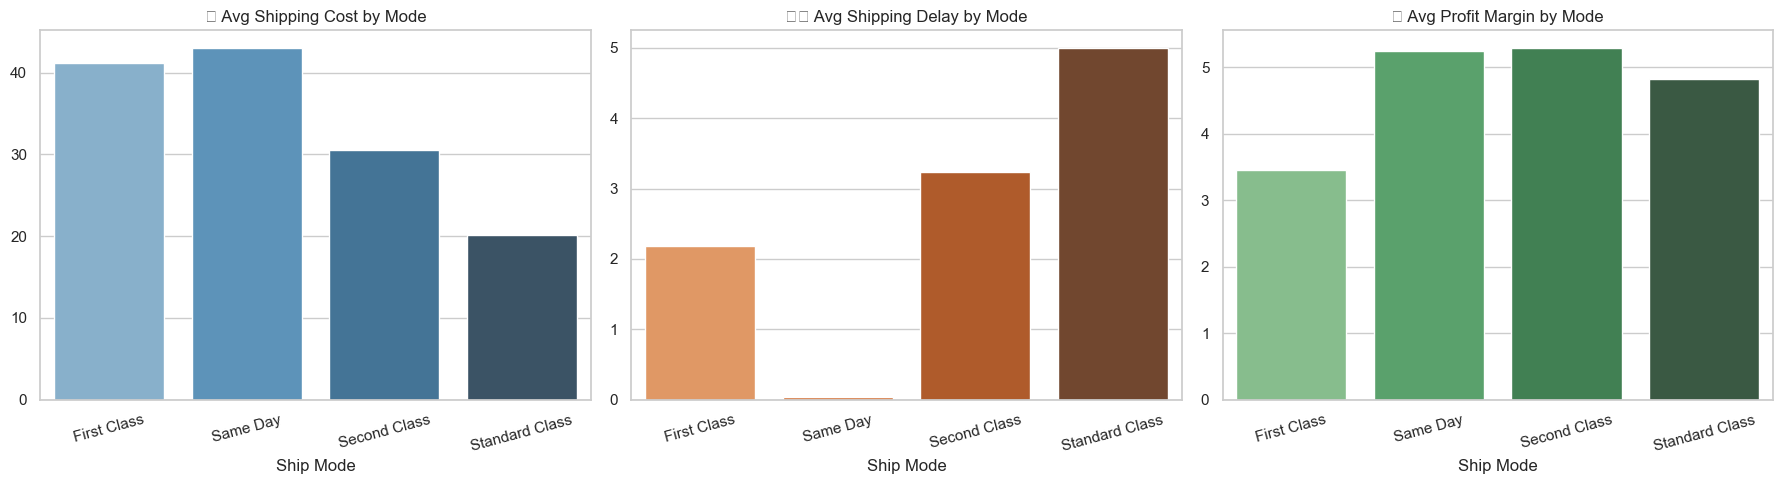

In [6]:
# Step 1: Group by Ship Mode
ship_mode_perf = df.groupby('Ship_Mode').agg({
    'Shipping_Cost': 'mean',
    'Shipping_Delay_Days': 'mean',
    'Profit_Margin': 'mean'
}).reset_index().round(2)

display(ship_mode_perf)

# Step 2: Bar Chart - Shipping Cost, Delay, and Profit Margin by Mode
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=ship_mode_perf, x='Ship_Mode', y='Shipping_Cost', ax=axes[0], palette='Blues_d')
axes[0].set_title("💰 Avg Shipping Cost by Mode")

sns.barplot(data=ship_mode_perf, x='Ship_Mode', y='Shipping_Delay_Days', ax=axes[1], palette='Oranges_d')
axes[1].set_title("⏱️ Avg Shipping Delay by Mode")

sns.barplot(data=ship_mode_perf, x='Ship_Mode', y='Profit_Margin', ax=axes[2], palette='Greens_d')
axes[2].set_title("📊 Avg Profit Margin by Mode")

for ax in axes:
    ax.set_xlabel("Ship Mode")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()

### 🚚 Shipping Mode Efficiency Summary

- 📦 **Same Day** and **First Class** have the **highest shipping costs** ($43.00 and $41.12), but **Same Day** delivers the fastest (0.04 days).
- ⏳ **Standard Class** is the **slowest** (5 days) but also **cheapest** ($20.09), offering decent margin (4.83%).
- 💡 **Second Class** offers the **best balance**: low cost ($30.56), reasonable speed (3.23 days), and the **highest profit margin (5.29%)**.

✅ **Recommendation**: Favor **Second Class** and **Standard Class** for cost-effective shipping unless ultra-fast delivery is essential.

---

## Shipping Delay Analysis

Objective:

Analyze how shipping delays vary across:
- 🌍 Regions
- 📦 Product Categories
- 🚚 Shipping Modes

Also, evaluate whether shipping delays impact profitability.

Steps:
1.	Group by Region, Category, and Ship_Mode
2.	Calculate average:
    - Shipping_Delay_Days
	- Profit_Margin
3.	Visualize:
	- 📊 Bar plots of average delay
	- 📈 Scatter plot of Shipping Delay vs Profit Margin

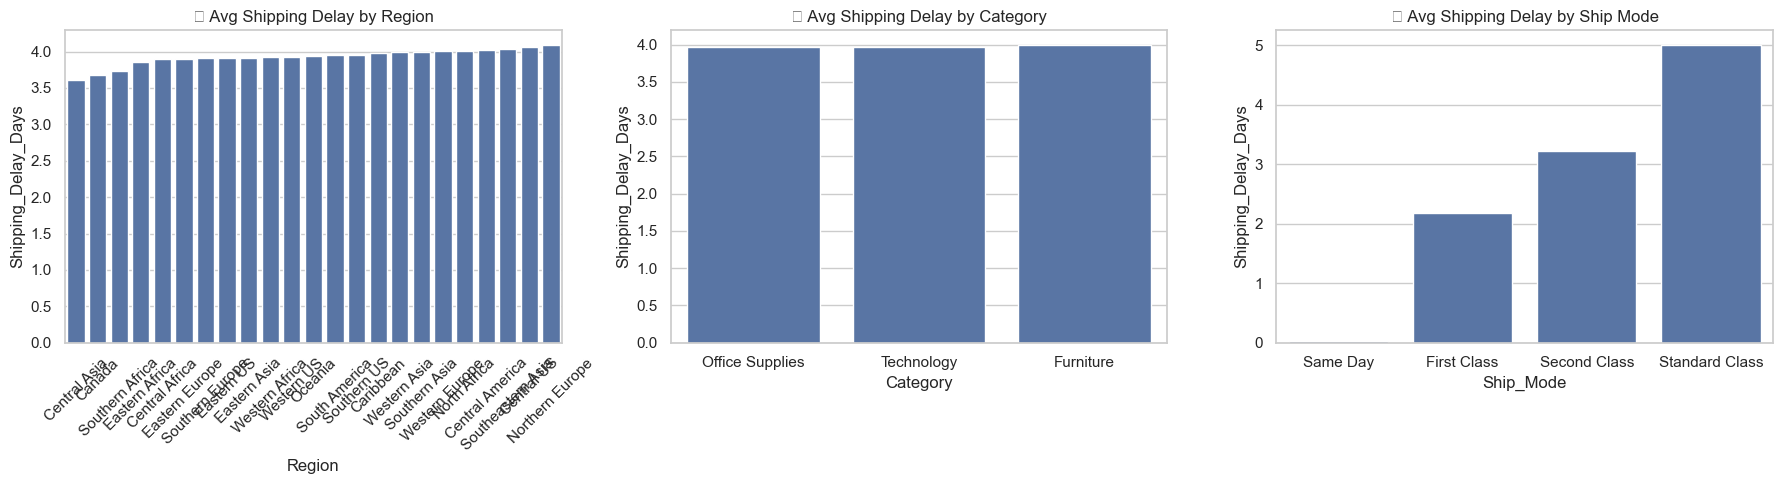

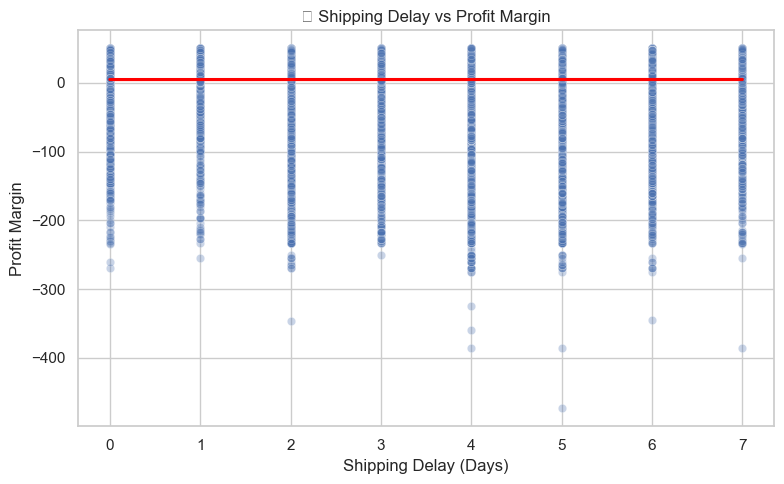

📊 Correlation between Shipping Delay and Profit Margin: 0.00


In [7]:
# Step 1: Avg delay by Region
delay_region = df.groupby('Region')['Shipping_Delay_Days'].mean().sort_values().reset_index()

# Step 2: Avg delay by Category
delay_category = df.groupby('Category')['Shipping_Delay_Days'].mean().sort_values().reset_index()

# Step 3: Avg delay by Ship Mode
delay_mode = df.groupby('Ship_Mode')['Shipping_Delay_Days'].mean().sort_values().reset_index()

# Step 4: Plot delays
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=delay_region, x='Region', y='Shipping_Delay_Days', ax=axes[0])
axes[0].set_title("🌍 Avg Shipping Delay by Region")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=delay_category, x='Category', y='Shipping_Delay_Days', ax=axes[1])
axes[1].set_title("📦 Avg Shipping Delay by Category")

sns.barplot(data=delay_mode, x='Ship_Mode', y='Shipping_Delay_Days', ax=axes[2])
axes[2].set_title("🚚 Avg Shipping Delay by Ship Mode")

plt.tight_layout()
plt.show()

# Step 5: Correlation – Delay vs Profit Margin
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Shipping_Delay_Days', y='Profit_Margin', alpha=0.3)
sns.regplot(data=df, x='Shipping_Delay_Days', y='Profit_Margin', scatter=False, color='red')
plt.title("📈 Shipping Delay vs Profit Margin")
plt.xlabel("Shipping Delay (Days)")
plt.ylabel("Profit Margin")
plt.tight_layout()
plt.show()

# Step 6: Correlation value
correlation = df['Shipping_Delay_Days'].corr(df['Profit_Margin'])
print(f"📊 Correlation between Shipping Delay and Profit Margin: {correlation:.2f}")

###  ⏱️ Shipping Delay Analysis Summary

- 📍 **No significant correlation** (r = 0.00) between **shipping delays** and **profit margin**.
- 🌍 Regional and category-level delays vary, but they do **not directly impact profitability**.
- 🚚 Shipping Mode affects delays as expected:
  - **Same Day**: Fastest (~0 days)
  - **Standard Class**: Slowest (~5 days)

✅ While delays don't hurt profit directly, they may affect **customer satisfaction** — worth monitoring alongside return rates and reviews.

---

## Shipping Cost vs Profit Margin

Objective:

Analyze whether higher shipping costs (especially as a percentage of sales) reduce profit margins.

This helps determine if expensive shipping options are eroding profitability across products, regions, or order types.

Steps:
1.	Use Shipping_Cost_Percent vs Profit_Margin
2.	Calculate correlation
3.	Visualize:
    - 📉 Scatter plot with regression line
4.	Optional: Run a basic OLS regression

📊 Correlation between Shipping Cost % and Profit Margin: -0.141


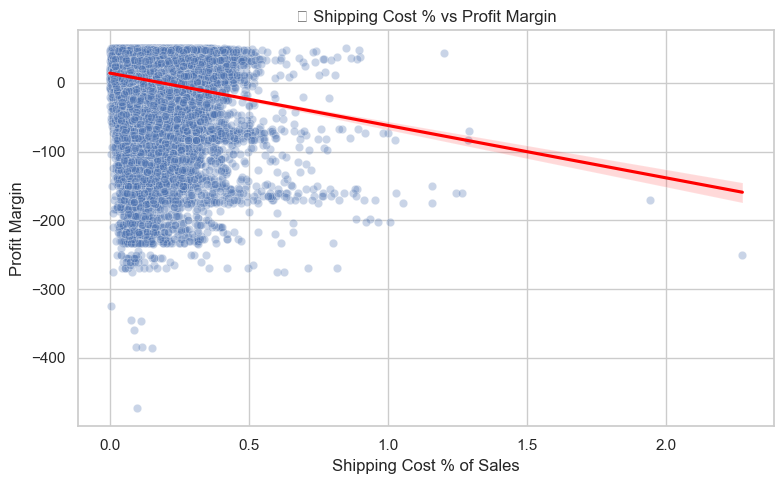

In [8]:
# Step 1: Correlation between shipping cost % and profit margin
corr_shipping_profit = df['Shipping_Cost_Percent'].corr(df['Profit_Margin'])
print(f"📊 Correlation between Shipping Cost % and Profit Margin: {corr_shipping_profit:.3f}")

# Step 2: Scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Shipping_Cost_Percent', y='Profit_Margin', alpha=0.3)
sns.regplot(data=df, x='Shipping_Cost_Percent', y='Profit_Margin', scatter=False, color='red')
plt.title("📉 Shipping Cost % vs Profit Margin")
plt.xlabel("Shipping Cost % of Sales")
plt.ylabel("Profit Margin")
plt.tight_layout()
plt.show()

## 📉 Shipping Cost vs Profit Margin

- 📊 **Correlation**: -0.14  
  There’s a **weak negative relationship** — as **shipping cost % of sales increases**, **profit margin slightly decreases**.

- 🧾 Interpretation:
  - High shipping costs do not completely kill profit, but they **chip away at margins** over time.
  - This is more relevant in **low-margin product categories** or regions with high logistics costs.

✅ **Recommendation**:
- Optimize shipping in **low-margin, high-cost regions**.
- Consider **bundling**, **threshold-based free shipping**, or **alternate carriers** to protect margin.

---

## 🧠 Final Insights & Strategic Recommendations

### 🚚 1. Shipping Costs Impact Margins
- Average shipping cost: **$26.48** per order
- On average, shipping eats up **~12.3% of sales**
- Weak **negative correlation** with profit margin (**-0.14**), but enough to justify optimization


### 🌍 2. Regional & Category Variance
- Regions like **Oceania** and **South America** have **higher shipping cost %**
- Product categories like **Furniture** carry higher logistics costs
- 📦 **Office Supplies** are typically low-cost and logistics-efficient



### 🚛 3. Shipping Mode Efficiency
- **Second Class** offers the **best balance** of cost, speed, and profitability
- **Same Day** is fast but expensive — use only where customer urgency justifies it



### ⏱️ 4. Shipping Delays Have No Direct Impact on Profit
- Correlation between **Shipping Delay** and **Profit Margin**: **0.00**
- But excessive delays may affect **customer satisfaction** and return rates — monitor externally



### 📌 Recommendations

#### 🔧 Operational
- **Optimize costly regions** (Oceania, South America) by renegotiating rates or bundling
- Focus on **Second Class and Standard Class** for efficient shipping
- Avoid aggressive discounting where shipping costs are already high

#### 🌐 Strategic
- Consider logistics hubs or alternative couriers in **high-cost markets**
- Track delays + returns together for better customer service insight



✅ This shipping analysis supports **data-driven logistics strategy** — balancing cost, speed, and profitability across modes and markets.